In [33]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc, roc_auc_score
)
from collections import Counter


In [9]:
plt.style.use("seaborn-whitegrid")
sns.set_palette("Set2")

In [10]:
# 1️ LOAD DỮ LIỆU

df = pd.read_csv("data_users.csv", encoding="utf-8", dtype=str)
print(f"Mô tả Dữ liệu gốc: {df.shape}")

def standardize_id(x):
    try:
        return str(int(float(x)))
    except:
        return None

df['user_id'] = df['steamid'].apply(standardize_id)
df = df.dropna(subset=['user_id'])

num_cols = ["total_playtime_hours", "account_age_years", "social_factor"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

node_features = df[[
    "user_id", "group_names", "loccountrycode", "locstatecode",
    "total_playtime_hours", "account_age_years", "social_factor",
    "friend_steamids_list"
]].copy()

node_dict = {}
for idx, row in node_features.iterrows():
    node_dict[row['user_id']] = {
        'group_names': row['group_names'],
        'loccountrycode': row['loccountrycode'],
        'locstatecode': row['locstatecode'],
        'total_playtime_hours': row['total_playtime_hours'],
        'account_age_years': row['account_age_years'],
        'social_factor': row['social_factor']
    }

print(f"Số node trong features: {len(node_dict)}")

# KHÔNG CÓ PHẦN BỔ SUNG THÔNG TIN CỤM (same_cluster)

def parse_friends(x):
    if pd.isna(x): 
        return []
    friends = []
    for f in str(x).split('|'):
        f = f.strip() 
        if not f: 
            continue
        try:
            friend_id = str(int(float(f)))
            if friend_id in node_dict: 
                friends.append(friend_id)
        except:
            continue
    return friends

Mô tả Dữ liệu gốc: (1482, 27)
Số node trong features: 1481


In [11]:
# 2️ XÂY DỰNG ĐỒ THỊ
all_edges = []
for _, r in df.iterrows():
    u = r['user_id']
    for f in parse_friends(r['friend_steamids_list']):
        if f != u and u in node_dict:
            if f in node_dict:
                all_edges.append(tuple(sorted((u, f))))

all_edges = list(set(all_edges))
print(f"Tổng số cạnh gốc: {len(all_edges)}")

E_train, E_test = train_test_split(all_edges, test_size=0.2, random_state=42)
G_train = nx.Graph()
G_train.add_edges_from(E_train)
valid_nodes = list(G_train.nodes())

print(f"Đồ thị G_train: {G_train.number_of_nodes()} node, {G_train.number_of_edges()} cạnh")
print(f"Tập cạnh Test : {len(E_test)} cạnh")

Tổng số cạnh gốc: 57794
Đồ thị G_train: 1481 node, 46235 cạnh
Tập cạnh Test : 11559 cạnh


In [12]:
# 1. LOAD FILE CHỨA KẾT QUẢ PHÂN CỤM
df_clusters = pd.read_csv("nodes_clusters.csv", dtype={'id': str}) 
print(f"File clusters da load: {df_clusters.shape}")
    
    # 2. CHỌN NHÃN CỤM VÀ CHUYỂN THÀNH DICTIONARY
cluster_map = df_clusters.set_index('id')['louvain'].to_dict()

    # 3. BỔ SUNG NHÃN CỤM VÀO node_dict
nodes_updated = 0
for user_id in node_dict:
    label = cluster_map.get(user_id, -1)
    node_dict[user_id]['cluster_label'] = label 
    if label != -1:
        nodes_updated += 1
print(f"Da them nhan cum Louvain vao {nodes_updated}/{len(node_dict)} node trong node_dict.")



File clusters da load: (1481, 6)
Da them nhan cum Louvain vao 1481/1481 node trong node_dict.


In [13]:
# 3️ TRÍCH XUẤT ĐẶC TRƯNG
def extract_features(u, v, G_base):
    features = {
        "shortest_path": 100,
        "common_friends": 0,
        "jaccard": 0,
        "pref_attachment": 0,
        "adamic_adar": 0,
        "common_groups": 0,
        "same_country": 0,
        "same_state": 0,
        "playtime_diff": 0,
        "account_age_diff": 0,
        "social_factor_diff": 0,
        "same_cluster": 0
    }
    
    if u not in node_dict or v not in node_dict:
        return features
    
    try:
        node_u = node_dict[u]
        node_v = node_dict[v]
        
        if G_base.has_node(u) and G_base.has_node(v):
            neighbors_u = set(G_base.neighbors(u))
            neighbors_v = set(G_base.neighbors(v))
            
            try:
                features["shortest_path"] = nx.shortest_path_length(G_base, u, v)
            except nx.NetworkXNoPath:
                features["shortest_path"] = 100
            
            common_friends = len(neighbors_u & neighbors_v)
            features["common_friends"] = common_friends
            
            total_neighbors = len(neighbors_u | neighbors_v)
            features["jaccard"] = common_friends / total_neighbors if total_neighbors > 0 else 0
            features["pref_attachment"] = len(neighbors_u) * len(neighbors_v)
            
            adamic_adar = 0
            for common in neighbors_u & neighbors_v:
                if G_base.has_node(common):
                    degree = G_base.degree(common)
                    if degree > 1:
                        adamic_adar += 1 / np.log(degree)
            features["adamic_adar"] = adamic_adar
        
        country_u = str(node_u.get('loccountrycode'))
        country_v = str(node_v.get('loccountrycode'))
        features["same_country"] = 1 if country_u == country_v and country_u != "" else 0
        
        state_u = str(node_u.get('locstatecode'))
        state_v = str(node_v.get('locstatecode'))
        features["same_state"] = 1 if state_u == state_v and state_u != "" else 0
        
        try:
            groups_u = set(str(node_u['group_names']).split("|")) if not pd.isna(node_u['group_names']) else set()
            groups_v = set(str(node_v['group_names']).split("|")) if not pd.isna(node_v['group_names']) else set()
            features["common_groups"] = len(groups_u & groups_v)
        except:
            features["common_groups"] = 0
        
        playtime_u = float(node_u['total_playtime_hours']) if not pd.isna(node_u['total_playtime_hours']) else 0
        playtime_v = float(node_v['total_playtime_hours']) if not pd.isna(node_v['total_playtime_hours']) else 0
        features["playtime_diff"] = abs(playtime_u - playtime_v)
        
        age_u = float(node_u['account_age_years']) if not pd.isna(node_u['account_age_years']) else 0
        age_v = float(node_v['account_age_years']) if not pd.isna(node_v['account_age_years']) else 0
        features["account_age_diff"] = abs(age_u - age_v)
        
        social_u = float(node_u['social_factor']) if not pd.isna(node_u['social_factor']) else 0
        social_v = float(node_v['social_factor']) if not pd.isna(node_v['social_factor']) else 0
        features["social_factor_diff"] = abs(social_u - social_v)
        cluster_u = node_u.get('cluster_label', -1)
        cluster_v = node_v.get('cluster_label', -1)
        
        # So sánh nhãn cụm (khác -1)
        if cluster_u != -1 and cluster_v != -1:
            features["same_cluster"] = 1 if cluster_u == cluster_v else 0
    except Exception:
        pass
    return features

In [14]:
# 4️ TẠO Positive Negative
def create_balanced_dataset_split(G_train, E_test, node_dict, n_samples=None):
    n_positive = len(E_test)
    if n_samples:
        n_positive = min(n_positive, n_samples // 2)
        positive_pairs = random.sample(E_test, n_positive)
    else:
        positive_pairs = E_test
        
    print(f"Positive pairs: {len(positive_pairs)}")
    
    negative_pairs = []
    valid_nodes = list(G_train.nodes())
    target_fof = n_positive // 2
    fof_candidates = [n for n, degree in G_train.degree() if degree >= 2]
    random.shuffle(fof_candidates)

    for node in fof_candidates:
        if len(negative_pairs) >= target_fof:
            break
        neighbors = list(G_train.neighbors(node))
        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                u, v = neighbors[i], neighbors[j]
                pair = tuple(sorted((u, v)))
                if pair not in all_edges and pair not in negative_pairs:
                    negative_pairs.append(pair)
                    if len(negative_pairs) >= target_fof:
                        break
            if len(negative_pairs) >= target_fof:
                break
    
    remaining = n_positive - len(negative_pairs)
    attempts = 0
    while len(negative_pairs) < n_positive and attempts < remaining * 10:
        u, v = random.sample(valid_nodes, 2)
        pair = tuple(sorted((u, v)))
        if pair not in all_edges and pair not in negative_pairs:
            negative_pairs.append(pair)
        attempts += 1
    
    print(f"Negative pairs: {len(negative_pairs)}")
    
    X_data, y_data = [], []
    for u, v in positive_pairs:
        X_data.append(extract_features(u, v, G_train))
        y_data.append(1)
    for u, v in negative_pairs:
        X_data.append(extract_features(u, v, G_train))
        y_data.append(0)
    
    X_df = pd.DataFrame(X_data)
    y_series = pd.Series(y_data)
    print(f"Phân bố nhãn: {np.unique(y_series, return_counts=True)}")
    return X_df, y_series

X, y = create_balanced_dataset_split(G_train, E_test, node_dict, n_samples=2000)

Positive pairs: 1000
Negative pairs: 1000
Phân bố nhãn: (array([0, 1], dtype=int64), array([1000, 1000], dtype=int64))


In [15]:
# 5️ TIỀN XỬ LÝ
positive_mask = y == 1
negative_mask = y == 0
for feature in X.columns:
    pos_mean = X[positive_mask][feature].mean()
    neg_mean = X[negative_mask][feature].mean()
    print(f"{feature:20} | Positive: {pos_mean:8.4f} | Negative: {neg_mean:8.4f}")

X = X.fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

shortest_path        | Positive:   2.0790 | Negative:   2.1170
common_friends       | Positive:  10.3630 | Negative:   5.6550
jaccard              | Positive:   0.0510 | Negative:   0.0330
pref_attachment      | Positive: 8166.0140 | Negative: 5323.7380
adamic_adar          | Positive:   2.2028 | Negative:   1.2333
common_groups        | Positive:   0.5690 | Negative:   0.5000
same_country         | Positive:   0.4410 | Negative:   0.3770
same_state           | Positive:   0.1560 | Negative:   0.1800
playtime_diff        | Positive: 4393.0646 | Negative: 4636.0371
account_age_diff     | Positive:   2.4372 | Negative:   2.2554
social_factor_diff   | Positive:   2.4557 | Negative:   2.4878
same_cluster         | Positive:   0.5340 | Negative:   0.3690
Training set: (1400, 12)
Test set: (600, 12)


Huấn luyện: Decision Tree
Decision Tree        | Acc: 0.6017 | Prec: 0.6000 | Rec: 0.6100 | F1: 0.6050 | AUC: 0.6416
Huấn luyện: Random Forest
Random Forest        | Acc: 0.6067 | Prec: 0.6185 | Rec: 0.5567 | F1: 0.5860 | AUC: 0.6778
Huấn luyện: KNN
KNN                  | Acc: 0.5783 | Prec: 0.5867 | Rec: 0.5300 | F1: 0.5569 | AUC: 0.5993
Huấn luyện: Logistic Regression
Logistic Regression  | Acc: 0.6050 | Prec: 0.6226 | Rec: 0.5333 | F1: 0.5745 | AUC: 0.6394

Bảng kết quả:
                 Model  Accuracy  Precision  Recall      F1     AUC
0        Decision Tree    0.6017     0.6000  0.6100  0.6050  0.6416
1        Random Forest    0.6067     0.6185  0.5567  0.5860  0.6778
2                  KNN    0.5783     0.5867  0.5300  0.5569  0.5993
3  Logistic Regression    0.6050     0.6226  0.5333  0.5745  0.6394

Mô hình tốt nhất: Random Forest (AUC = 0.6778)


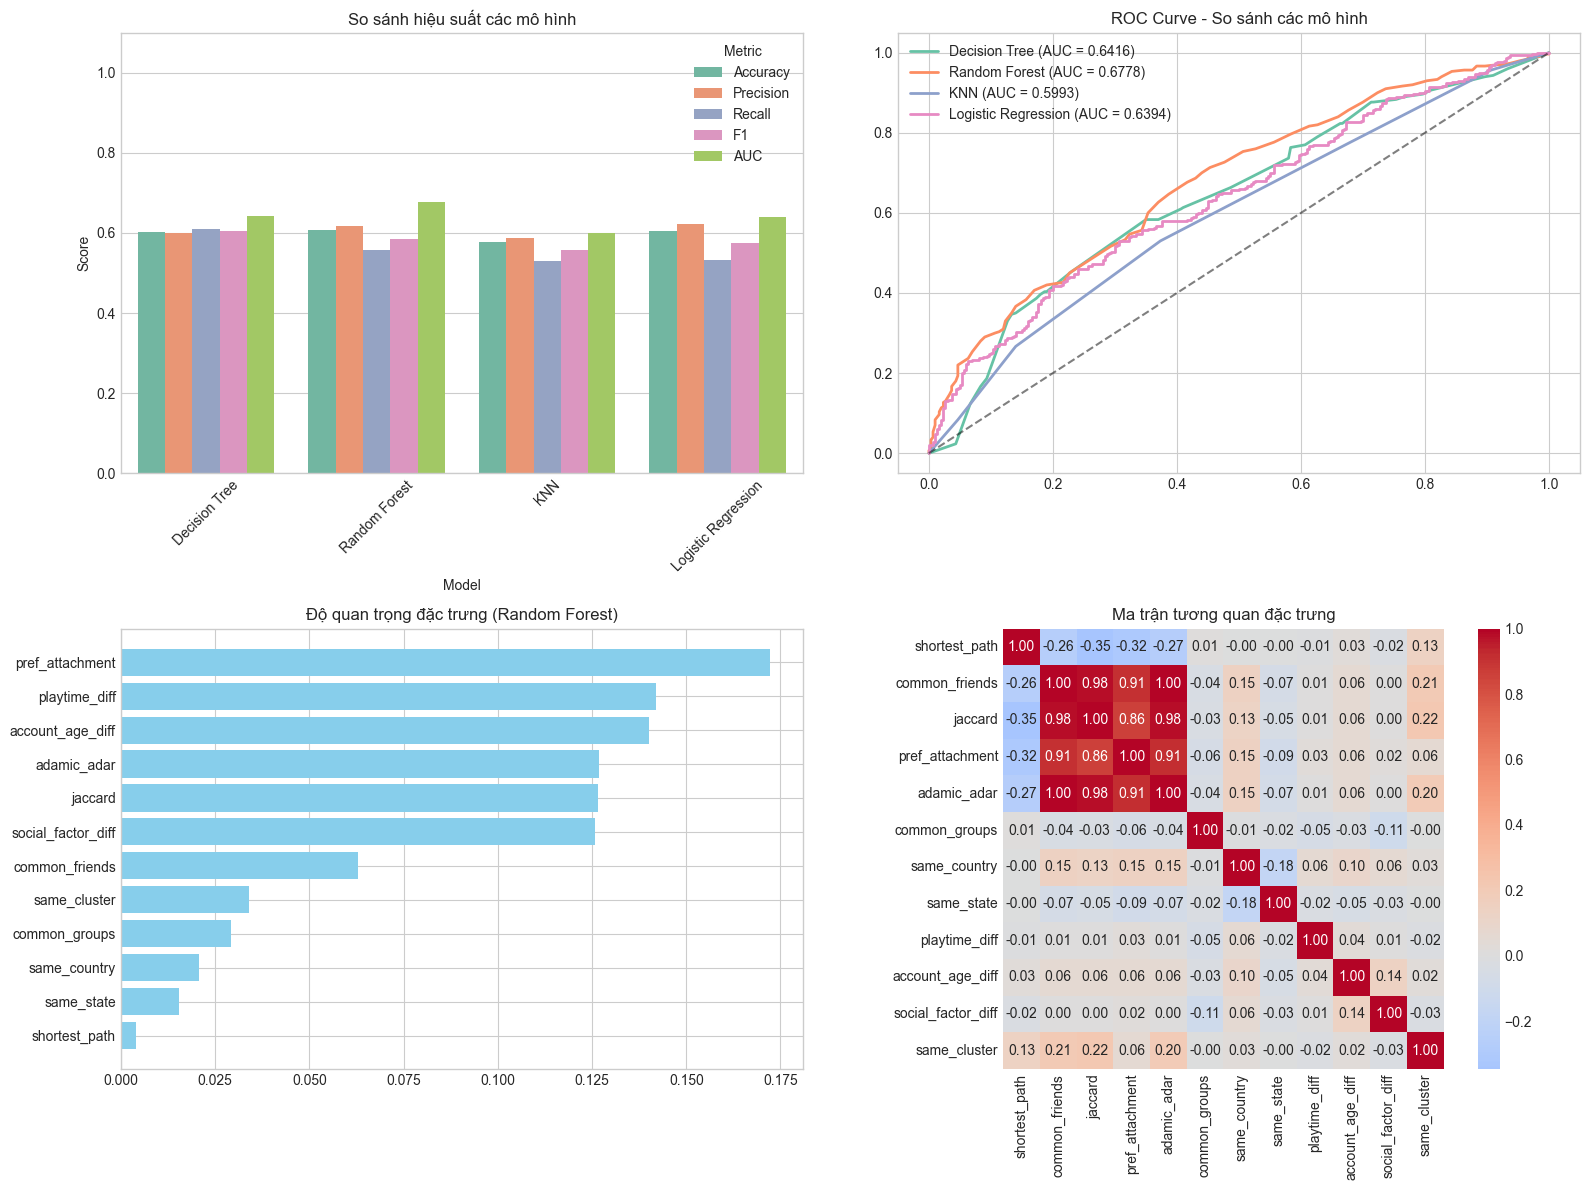

In [16]:
# 6️ HUẤN LUYỆN VÀ ĐÁNH GIÁ
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
}
results = []
roc_data = {}

for name, model in models.items():
    print(f"Huấn luyện: {name}")
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-8)
        auc_score = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_data[name] = (fpr, tpr, auc_score)
        results.append([name, accuracy, precision, recall, f1, auc_score])
        print(f"{name:20} | Acc: {accuracy:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f} | F1: {f1:.4f} | AUC: {auc_score:.4f}")
    except Exception as e:
        print(f"Lỗi {name}: {e}")
        results.append([name, np.nan, np.nan, np.nan, np.nan, np.nan])

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"])
print("\nBảng kết quả:")
print(df_results.round(4))

best_model_idx = df_results['AUC'].idxmax()
best_model_name = df_results.loc[best_model_idx, 'Model']
best_model_auc = df_results.loc[best_model_idx, 'AUC']
print(f"\nMô hình tốt nhất: {best_model_name} (AUC = {best_model_auc:.4f})")

# Biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].set_title("So sánh hiệu suất các mô hình")
metrics_df = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=metrics_df, x="Model", y="Score", hue="Metric", ax=axes[0,0])
axes[0,0].set_ylim(0, 1.1)
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].set_title("ROC Curve - So sánh các mô hình")
for name, (fpr, tpr, auc_score) in roc_data.items():
    axes[0,1].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)
axes[0,1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0,1].legend()

if "Random Forest" in models:
    axes[1,0].set_title("Độ quan trọng đặc trưng (Random Forest)")
    feature_imp = pd.DataFrame({
        'feature': X.columns,
        'importance': models["Random Forest"].feature_importances_
    }).sort_values('importance', ascending=True)
    axes[1,0].barh(feature_imp['feature'], feature_imp['importance'], color='skyblue')
else:
    axes[1,0].text(0.5, 0.5, "Không khả dụng", ha='center', va='center')

axes[1,1].set_title("Ma trận tương quan đặc trưng")
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[1,1])

plt.tight_layout()
plt.show()

In [17]:
# 7️ DỰ ĐOÁN LIÊN KẾT MỚI
best_model = models[best_model_name]
candidate_pairs = []
all_nodes_in_G_train = list(G_train.nodes())

for _ in range(1000):
    u, v = np.random.choice(all_nodes_in_G_train, 2, replace=False)
    pair = tuple(sorted((u, v)))
    if pair not in all_edges:
        candidate_pairs.append((u, v))

predictions = []
for i, (u, v) in enumerate(candidate_pairs, 1):
    features = extract_features(u, v, G_train)
    X_new = scaler.transform(pd.DataFrame([features]))
    prob = best_model.predict_proba(X_new)[0, 1]
    predictions.append((u, v, prob))
    status = 'CÓ TIỀM NĂNG' if prob > 0.6 else ('NGHIÊNG VỀ KHẢ NĂNG' if prob > 0.5 else 'ÍT TIỀM NĂNG')
    print(f"{i:2d}. {u} - {v} | Xác suất: {prob:.4f} | {status}")

df_predictions = pd.DataFrame(predictions, columns=["User_A", "User_B", "Link_Probability"])
print("\nBảng tổng hợp dự đoán:")
print(df_predictions.sort_values("Link_Probability", ascending=False).round(4))


 1. 76561198218306592 - 76561198083747120 | Xác suất: 0.4900 | ÍT TIỀM NĂNG
 2. 76561198851587040 - 76561198137565696 | Xác suất: 0.3700 | ÍT TIỀM NĂNG
 3. 76561198191985920 - 76561198050086064 | Xác suất: 0.2400 | ÍT TIỀM NĂNG
 4. 76561198163183216 - 76561197976576384 | Xác suất: 0.5700 | NGHIÊNG VỀ KHẢ NĂNG
 5. 76561198955551424 - 76561198281791984 | Xác suất: 0.7300 | CÓ TIỀM NĂNG
 6. 76561198427491312 - 76561198196545504 | Xác suất: 0.2800 | ÍT TIỀM NĂNG
 7. 76561199159570928 - 76561198132321056 | Xác suất: 0.5600 | NGHIÊNG VỀ KHẢ NĂNG
 8. 76561198047916352 - 76561198064278176 | Xác suất: 0.3600 | ÍT TIỀM NĂNG
 9. 76561198315020144 - 76561198157492512 | Xác suất: 0.2800 | ÍT TIỀM NĂNG
10. 76561198135543200 - 76561198116996992 | Xác suất: 0.5300 | NGHIÊNG VỀ KHẢ NĂNG
11. 76561198112834208 - 76561198027620256 | Xác suất: 0.3700 | ÍT TIỀM NĂNG
12. 76561198217508432 - 76561197964782864 | Xác suất: 0.5100 | NGHIÊNG VỀ KHẢ NĂNG
13. 76561198320990048 - 76561198057417392 | Xác suất: 0.4800

C:\Users\Loc\AppData\Local\Temp\ipykernel_9516\412158429.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Link_Probability', y='Pair_ID', data=df_top10, palette='Blues_d')


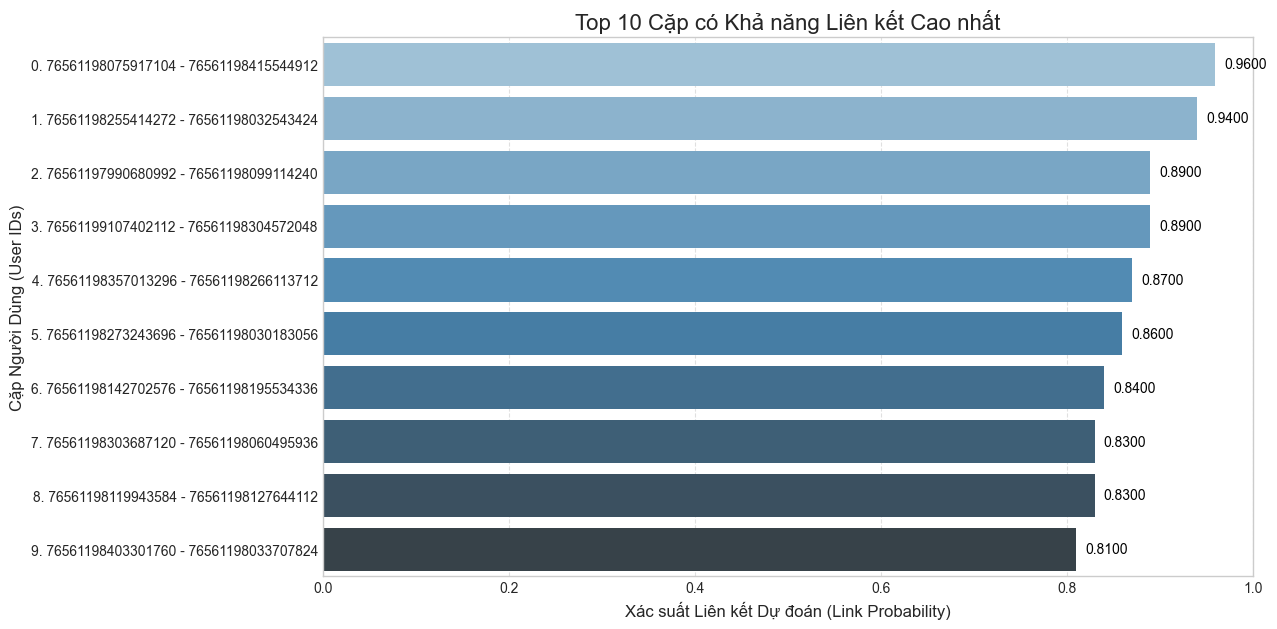

In [20]:
#Biểu đồ Thanh Top 10 Cặp Tiềm năng
# Lấy Top 10 cặp có xác suất cao nhất
df_top10 = df_predictions.sort_values("Link_Probability", ascending=False).head(10).reset_index(drop=True)
df_top10['Pair_ID'] = df_top10.index.map(str) + '. ' + df_top10['User_A'].astype(str) + ' - ' + df_top10['User_B'].astype(str)

plt.figure(figsize=(12, 7))
# Sử dụng màu xanh đậm hơn để nổi bật kết quả
sns.barplot(x='Link_Probability', y='Pair_ID', data=df_top10, palette='Blues_d')
plt.title('Top 10 Cặp có Khả năng Liên kết Cao nhất', fontsize=16)
plt.xlabel('Xác suất Liên kết Dự đoán (Link Probability)', fontsize=12)
plt.ylabel('Cặp Người Dùng (User IDs)', fontsize=12)
plt.xlim(0, 1) # Đặt giới hạn xác suất từ 0 đến 1
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Thêm giá trị xác suất vào các thanh
for index, row in df_top10.iterrows():
    plt.text(row['Link_Probability'] + 0.01, index, f"{row['Link_Probability']:.4f}", color='black', va="center")

plt.show()

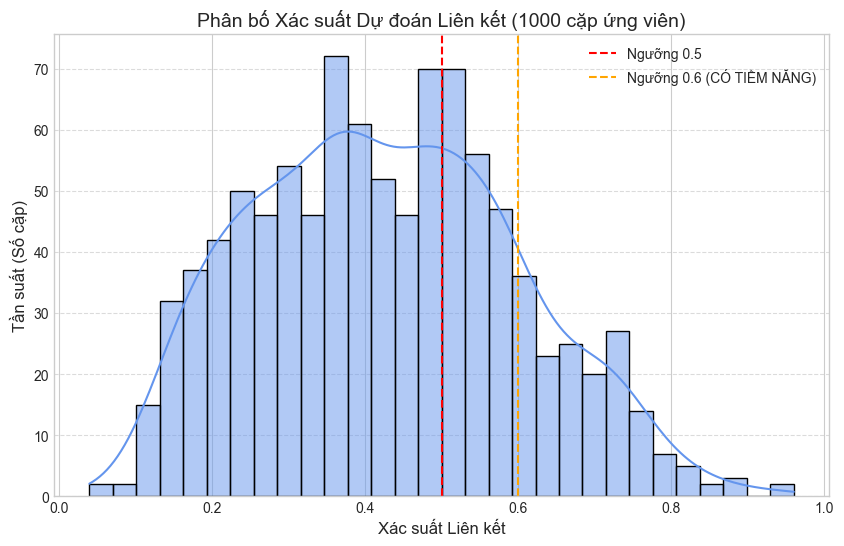

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df_predictions['Link_Probability'], bins=30, kde=True, color='cornflowerblue')
plt.title('Phân bố Xác suất Dự đoán Liên kết (1000 cặp ứng viên)', fontsize=14)
plt.xlabel('Xác suất Liên kết', fontsize=12)
plt.ylabel('Tần suất (Số cặp)', fontsize=12)
plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng 0.5')
plt.axvline(0.6, color='orange', linestyle='--', linewidth=1.5, label='Ngưỡng 0.6 (CÓ TIỀM NĂNG)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


C:\Users\Loc\AppData\Local\Temp\ipykernel_9516\3650618930.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df_predictions, palette='viridis', order=['ÍT TIỀM NĂNG', 'NGHIÊNG VỀ KHẢ NĂNG', 'CÓ TIỀM NĂNG'])


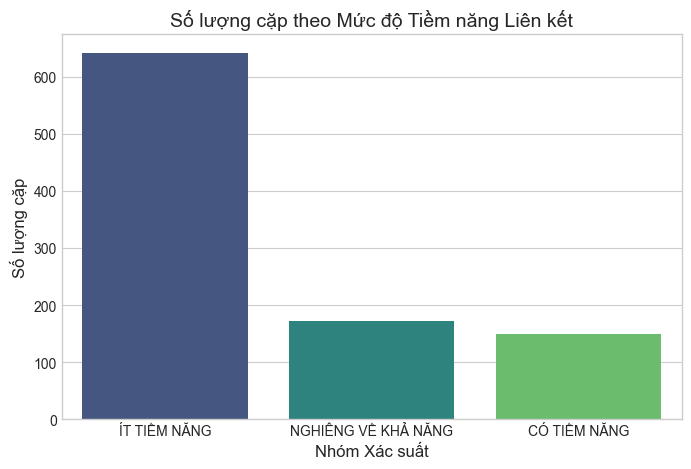

In [28]:
df_predictions['Category'] = df_predictions['Link_Probability'].apply(
    lambda p: 'CÓ TIỀM NĂNG' if p > 0.6 else ('NGHIÊNG VỀ KHẢ NĂNG' if p > 0.5 else 'ÍT TIỀM NĂNG')
)
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=df_predictions, palette='viridis', order=['ÍT TIỀM NĂNG', 'NGHIÊNG VỀ KHẢ NĂNG', 'CÓ TIỀM NĂNG'])
plt.title('Số lượng cặp theo Mức độ Tiềm năng Liên kết', fontsize=14)
plt.xlabel('Nhóm Xác suất', fontsize=12)
plt.ylabel('Số lượng cặp', fontsize=12)
plt.show()


C:\Users\Loc\AppData\Local\Temp\ipykernel_9516\276517655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Link_Probability', data=df_predictions, palette='Set2',


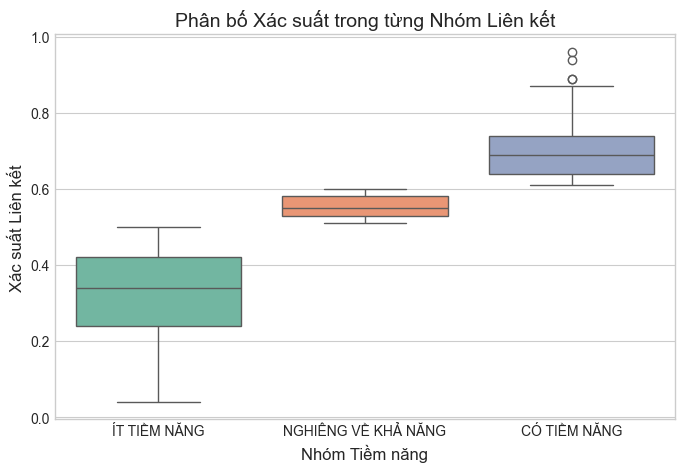

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Link_Probability', data=df_predictions, palette='Set2',
            order=['ÍT TIỀM NĂNG', 'NGHIÊNG VỀ KHẢ NĂNG', 'CÓ TIỀM NĂNG'])
plt.title('Phân bố Xác suất trong từng Nhóm Liên kết', fontsize=14)
plt.xlabel('Nhóm Tiềm năng', fontsize=12)
plt.ylabel('Xác suất Liên kết', fontsize=12)
plt.show()


C:\Users\Loc\AppData\Local\Temp\ipykernel_9516\3892985426.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='User', data=top_nodes, palette='mako')


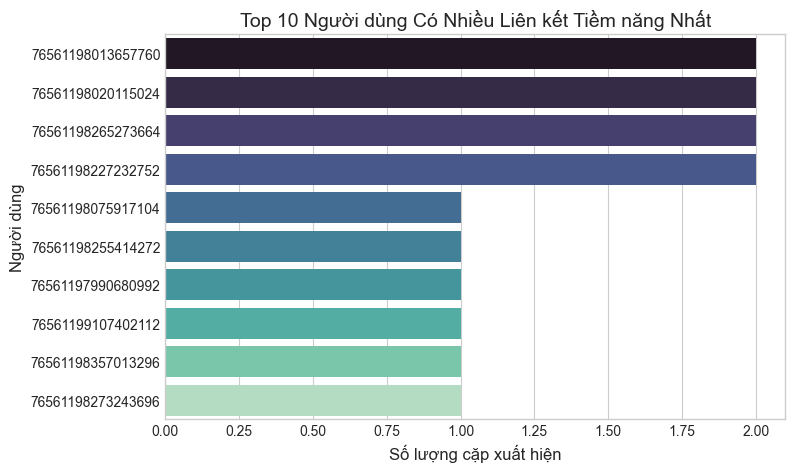

In [32]:
counts = Counter(top_links['User_A']) + Counter(top_links['User_B'])
top_nodes = pd.DataFrame(counts.most_common(10), columns=['User', 'Frequency'])

plt.figure(figsize=(8,5))
sns.barplot(x='Frequency', y='User', data=top_nodes, palette='mako')
plt.title('Top 10 Người dùng Có Nhiều Liên kết Tiềm năng Nhất', fontsize=14)
plt.xlabel('Số lượng cặp xuất hiện', fontsize=12)
plt.ylabel('Người dùng', fontsize=12)
plt.show()
